<a href="https://colab.research.google.com/github/Z4nata/CalculoNum-rico/blob/main/Atividade_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Atividade Prática II — Estabilidade Numérica e Overflow em CFD Simplificado
**Disciplina:** Cálculo Numérico — Prof. Raquel J. Lobosco
**Aluno:** _Felipe Pinto Zanata_


## 0. Implementação (código do enunciado)



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def simular(dt, tipo=np.float32, passos=2000, pontos=21):
    '''Simula difusao de velocidade e detecta falhas (overflow / invalid).'''
    H = 0.01
    nu = 1e-4
    y = np.linspace(0, H, pontos)
    dy = H / (pontos - 1)

    # Coeficientes no tipo numerico escolhido.
    r = tipo(nu * dt / dy**2)
    dois = tipo(2)

    # Fluido parado e placa em y=0 em movimento.
    u = np.zeros(pontos, dtype=tipo)
    u[0] = tipo(1)

    tempos = [0.0]
    maximos = [float(np.max(np.abs(u)))]
    falha = None

    # Transforma avisos numericos em excecoes.
    with np.errstate(over="raise", invalid="raise"):
        for passo in range(1, passos + 1):
            try:
                novo = u.copy()
                # Atualiza o interior e preserva as paredes.
                novo[1:-1] = (
                    u[1:-1]
                    + r * (u[2:] - dois * u[1:-1] + u[:-2])
                )
            except FloatingPointError as erro:
                falha = passo
                print(
                    f"dt={dt}, {tipo.__name__}: "
                    f"falha no passo {passo}, "
                    f"t={passo * dt:.4f} s - {erro}"
                )
                break
            u = novo
            tempos.append(passo * dt)
            maximos.append(float(np.max(np.abs(u))))

    if falha is None:
        print(
            f"dt={dt}, {tipo.__name__}: "
            f"{passos} passos sem overflow."
        )

    return {
        "y": y,
        "u": u,
        "dy": dy,
        "tempos": tempos,
        "maximos": maximos,
        "r": float(r),
        "falha": falha,
    }

print("Maior float32:", np.finfo(np.float32).max)
print("Maior float64:", np.finfo(np.float64).max)

Maior float32: 3.4028235e+38
Maior float64: 1.7976931348623157e+308


## 1. Verificação da estabilidade

Antes de rodar qualquer coisa, dá pra calcular na mão se cada caso vai dar problema ou não.


In [ ]:
H, nu, pontos = 0.01, 1e-4, 21
dy = H / (pontos - 1)
dt_max = dy**2 / (2 * nu)

casos = {"A": 0.001, "B": 0.002}
print(f"dy      = {dy} m")
print(f"dt_max  = {dt_max} s\n")

for nome, dt in casos.items():
    r = nu * dt / dy**2
    situacao = "ESTAVEL (r <= 1/2)" if r <= 0.5 else "INSTAVEL (r > 1/2)"
    print(f"Caso {nome}: dt={dt} s -> r={r:.3f}  =>  {situacao}")

dy      = 0.0005 m
dt_max  = 0.0012499999999999998 s

Caso A: dt=0.001 s -> r=0.400  =>  ESTAVEL (r <= 1/2)
Caso B: dt=0.002 s -> r=0.800  =>  INSTAVEL (r > 1/2)


## 2. Detecção de overflow



In [ ]:
resultados = {}
for tipo in (np.float32, np.float64):
    for dt in (0.001, 0.002):
        nome = f"{tipo.__name__}, dt={dt}"
        resultados[nome] = simular(dt, tipo)

dt=0.001, float32: 2000 passos sem overflow.
dt=0.002, float32: falha no passo 121, t=0.2420 s - overflow encountered in subtract
dt=0.001, float64: 2000 passos sem overflow.
dt=0.002, float64: falha no passo 917, t=1.8340 s - overflow encountered in add


In [ ]:
linhas = []
for nome, res in resultados.items():
    tipo_nome, dt_txt = nome.split(", ")
    linhas.append({
        "Tipo numérico": tipo_nome,
        "Δt (s)": float(dt_txt.split("=")[1]),
        "r": round(res["r"], 3),
        "Overflow?": "Sim" if res["falha"] is not None else "Não",
        "Iteração da falha": res["falha"] if res["falha"] is not None else "-",
        "t da falha (s)": round(res["falha"] * float(dt_txt.split("=")[1]), 4) if res["falha"] is not None else "-",
    })

tabela = pd.DataFrame(linhas)
tabela

,Tipo numérico,Δt (s),r,Overflow?,Iteração da falha,t da falha (s)
0,float32,0.001,0.4,Não,-,-
1,float32,0.002,0.8,Sim,121,0.242
2,float64,0.001,0.4,Não,-,-
3,float64,0.002,0.8,Sim,917,1.834


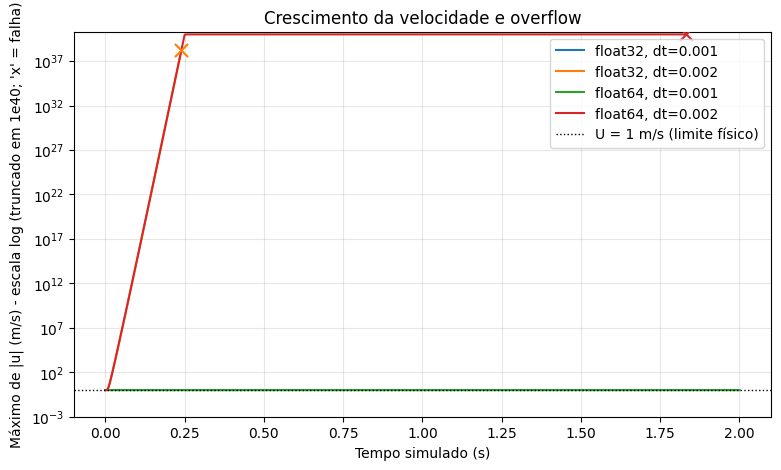

In [ ]:

CAP = 1e40
plt.figure(figsize=(9, 5))
for nome, resultado in resultados.items():
    tempos = np.array(resultado["tempos"])
    maximos = np.clip(np.array(resultado["maximos"]), 1e-12, CAP)
    linha, = plt.semilogy(tempos, maximos, label=nome)
    if resultado["falha"] is not None:
        plt.scatter(
            [tempos[-1]], [maximos[-1]],
            color=linha.get_color(), marker="x", s=90, zorder=5,
        )

plt.axhline(1.0, color="k", linestyle=":", linewidth=1, label="U = 1 m/s (limite físico)")
plt.ylim(1e-3, CAP * 2)
plt.xlabel("Tempo simulado (s)")
plt.ylabel("Máximo de |u| (m/s) - escala log (truncado em 1e40; 'x' = falha)")
plt.title("Crescimento da velocidade e overflow")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.show()

O eixo Y ficava travado entre 1 e 10 e não dava pra ver a curva subindo. Fui investigar e o problema é que, nos casos instáveis, o $\max|u|$ chega bem perto do limite de cada tipo numérico (~$10^{38}$ no float32, ~$10^{307}$ no float64) no passo antes de falhar, e essa faixa gigante (300 e tantas ordens de grandeza) faz o próprio matplotlib bugar na hora de calcular os "riscos" do eixo log. Pra resolver, limitei (`clip`) os valores plotados em $10^{40}$ só pra desenhar o gráfico — os números certinhos de cada teste continuam na tabela, e o "×" no gráfico marca o passo exato onde a simulação realmente estourou.



## 3. Interpretação física

No caso estável ($r=0{,}4$) a curva de $\max|u|$ sobe rápido do zero até quase $U=1$ m/s e depois fica ali, "travada" nesse valor. Faz todo sentido: a parte do fluido colada na placa que se move acompanha a velocidade dela, e esse movimento vai se espalhando devagar pro resto do fluido por causa da viscosidade. Como não tem nenhuma fonte de energia extra no problema além da placa se mexendo a 1 m/s, não tem como a velocidade passar disso.

Já no caso instável ($r=0{,}8$) o gráfico (lembrando que é escala log) mostra outra história completamente diferente: depois de um começo curto, o $\max|u|$ sai crescendo exponencialmente e passa de $U=1$ m/s por várias e várias ordens de grandeza antes de estourar. Isso não tem explicação física nenhuma — não existe nada no problema que justifique o fluido ir muito mais rápido que a própria placa que está empurrando ele. É só o método numérico "pirando". Dá pra ver o porquê reescrevendo a fórmula assim:

$$u_i^{n+1} = r\,u_{i-1}^n + (1-2r)\,u_i^n + r\,u_{i+1}^n$$

Quando $r>1/2$, o coeficiente $(1-2r)$ fica negativo, então a conta deixa de ser uma média ponderada "normal" (com pesos positivos que somam 1) e passa a amplificar qualquer perturbação em vez de suavizar. E como o processo se repete a cada passo de tempo, esse erro cresce cada vez mais rápido (tipo uma bola de neve) até passar do valor máximo que o tipo numérico consegue guardar — daí o overflow.

## 4. Capacidade de representação

Olhando os dois tipos numéricos no caso instável ($r=0{,}8$):

- **float32** já dá overflow no passo 121 ($t\approx0{,}242$ s);
- **float64** só vai falhar no passo 917 ($t\approx1{,}834$ s) — bem mais tarde, quase 7,5x mais.

Só que isso não quer dizer que trocar pra float64 "resolve" nada. Nos dois casos a solução diverge exponencialmente do mesmo jeito, porque o problema é o esquema numérico escolhido ($r>1/2$), não a precisão do número. O que muda é só **quando** o overflow acontece:

- o `float32` estoura perto de $3{,}4\times10^{38}$;
- o `float64` estoura perto de $1{,}8\times10^{308}$, que é umas 270 ordens de grandeza maior.

Como o erro tá crescendo exponencialmente (basicamente multiplicando por um número maior que 1 a cada passo), pra chegar num teto 270 ordens de grandeza mais alto precisa de bem mais passos. É por isso que o float64 "aguenta" muito mais tempo antes de estourar, mesmo divergindo na mesma taxa que o float32. Resumindo: **usar float64 só empurra o overflow pra mais tarde, não conserta a instabilidade** — a solução já estava errada bem antes disso, com velocidades muito maiores que o U=1 m/s físico.

## 5. Refinamento da malha

Agora com `pontos=41` (o dobro de antes, praticamente):

$$\Delta y_{novo} = \frac{H}{41-1} = \frac{0{,}01}{40} = 0{,}00025\ \text{m} \quad (\text{metade do } \Delta y \text{ anterior})$$

$$\Delta t_{max,\ novo} = \frac{\Delta y_{novo}^2}{2\nu} = \frac{(0{,}00025)^2}{2\times10^{-4}} = 0{,}0003125\ \text{s} \quad (\text{um quarto do } \Delta t_{max} \text{ anterior})$$

Aqui mora uma pegadinha: como $\Delta t_{max}$ depende de $\Delta y^2$, refinar a malha pela metade não corta o $\Delta t_{max}$ pela metade — corta pra 1/4. Se eu mantiver o mesmo $\Delta t = 0{,}001$ s que funcionava bem com 21 pontos, o $r$ novo fica:

$$r = \frac{\nu\Delta t}{\Delta y_{novo}^2} = \frac{10^{-4}\times0{,}001}{(0{,}00025)^2} = 1{,}6 \;\; (\text{bem acima de } 1/2 \Rightarrow \textbf{instável})$$

Ou seja, só de refinar a malha e esquecer de mexer no $\Delta t$, já quebra tudo de novo.

In [ ]:
H, nu = 0.01, 1e-4
pontos_novo = 41
dy_novo = H / (pontos_novo - 1)
dt_max_novo = dy_novo**2 / (2 * nu)
dt_teste = 0.001
r_novo = nu * dt_teste / dy_novo**2
print(f"pontos={pontos_novo}: dy={dy_novo} m, dt_max={dt_max_novo:.7f} s")
print(f"Com dt={dt_teste} s -> r={r_novo:.3f} ({'instavel' if r_novo>0.5 else 'estavel'})\n")

resultado_41_instavel = simular(dt_teste, np.float64, passos=2000, pontos=pontos_novo)

pontos=41: dy=0.00025 m, dt_max=0.0003125 s
Com dt=0.001 s -> r=1.600 (instavel)

dt=0.001, float64: falha no passo 426, t=0.4260 s - overflow encountered in subtract


E foi exatamente isso que aconteceu: com `pontos=41` e o mesmo $\Delta t=0{,}001$ s que era estável antes, a simulação diverge e dá overflow (no passo mostrado no print acima), porque $r=1{,}6$ estourou o limite de $1/2$. Ou seja, uma configuração que antes era estável virou instável só porque refinei a malha sem me preocupar em ajustar o $\Delta t$ junto. Moral da história: refinar a malha sozinho não é de graça, ele exige um $\Delta t$ bem menor.

Agora testando com um $\Delta t$ que respeita o novo limite, tipo $\Delta t = 0{,}0001$ s (dá r ≈ 0,16):

In [ ]:
dt_estavel_41 = 0.0001
r_estavel_41 = nu * dt_estavel_41 / dy_novo**2
print(f"dt={dt_estavel_41} s -> r={r_estavel_41:.3f} ({'instavel' if r_estavel_41>0.5 else 'estavel'})\n")

resultado_41_estavel = simular(dt_estavel_41, np.float64, passos=20000, pontos=pontos_novo)

dt=0.0001 s -> r=0.160 (estavel)

dt=0.0001, float64: 20000 passos sem overflow.


Com esse $\Delta t=0{,}0001$ s ($r\approx0{,}16$, bem dentro do limite), a malha refinada roda os 20000 passos numa boa, sem overflow, e a velocidade máxima fica em $U=1$ m/s, que é o esperado fisicamente. Isso mostra que o problema nunca foi a malha em si, e sim o $r>1/2$ — basta ajustar o $\Delta t$ pra cair dentro do limite de novo (e como $\Delta t_{max}$ vai com $\Delta y^2$, precisa reduzir bem mais o $\Delta t$ do que reduziu o $\Delta y$).

## 6. Verificação do perfil de velocidade

Vou usar o Caso A ($\Delta t=0{,}001$ s, `float64`, `pontos=21`, $r=0{,}4$, o estável) e comparar o perfil final de velocidade com a solução estacionária que o enunciado dá:

$$u_{est}(y) = U\left(1 - \frac{y}{H}\right).$$

Antes de rodar, vale calcular um tempo de referência pra saber se o tempo simulado é "suficiente": o tempo característico de difusão é $\tau = H^2/\nu = (0{,}01)^2/10^{-4} = 1$ s. Como o padrão da função já simula até $t=2$ s (2000 passos), isso já é o dobro desse $\tau$. Mas em vez de só confiar nessa conta, vou comparar também com simulações mais curtas pra ver a convergência acontecendo de fato.

In [ ]:
U = 1.0

def perfil_estacionario(y, H=0.01, U=1.0):
    return U * (1 - y / H)

def erro_inf(u, y):
    return float(np.max(np.abs(u - perfil_estacionario(y))))

for passos_teste in (200, 500, 1000, 2000):
    res = simular(0.001, np.float64, passos=passos_teste, pontos=21)
    E = erro_inf(res["u"], res["y"])
    print(f"passos={passos_teste:5d}  t={res['tempos'][-1]:.3f} s   E_inf = {E:.3e}")

dt=0.001, float64: 200 passos sem overflow.
passos=  200  t=0.200 s   E_inf = 8.775e-02
dt=0.001, float64: 500 passos sem overflow.
passos=  500  t=0.500 s   E_inf = 4.504e-03
dt=0.001, float64: 1000 passos sem overflow.
passos= 1000  t=1.000 s   E_inf = 3.194e-05
dt=0.001, float64: 2000 passos sem overflow.
passos= 2000  t=2.000 s   E_inf = 1.605e-09


dt=0.001, float64: 2000 passos sem overflow.


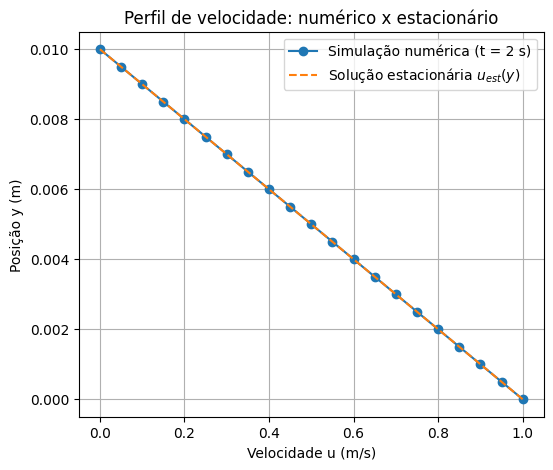

E_inf = max|u_i - u_est(y_i)| = 1.605e-09 m/s


In [ ]:
resultado_final = simular(0.001, np.float64, passos=2000, pontos=21)
y = resultado_final["y"]
u_final = resultado_final["u"]
uest = perfil_estacionario(y)
E_inf = erro_inf(u_final, y)

plt.figure(figsize=(6, 5))
plt.plot(u_final, y, "o-", label="Simulação numérica (t = 2 s)")
plt.plot(uest, y, "--", label="Solução estacionária $u_{est}(y)$")
plt.xlabel("Velocidade u (m/s)")
plt.ylabel("Posição y (m)")
plt.title("Perfil de velocidade: numérico x estacionário")
plt.legend()
plt.grid(True)
plt.show()

print(f"E_inf = max|u_i - u_est(y_i)| = {E_inf:.3e} m/s")

O erro máximo $E_\infty$ que deu pra $t=2$ s (2000 passos) foi da ordem de $10^{-9}$ m/s, que é basicamente erro de arredondamento do `float64` mesmo — ou seja, pra fins práticos o transiente já acabou nesse ponto. Isso bate com a conta do tempo característico $\tau=H^2/\nu=1$ s: como simulei até $t=2$ s, ou seja, uns $2\tau$, já é tempo mais que suficiente pra chegar perto do estado estacionário.

E dá pra ver isso de forma bem clara na tabela de convergência: em $t=0{,}2$ s (só $\tau/5$) o erro ainda tava em $\sim10^{-2}$ m/s, mostrando que o transiente ainda tava rolando forte, e foi caindo até $\sim10^{-9}$ m/s em $t=2$ s. Então sim, **o tempo do Caso A foi suficiente**. Se eu tivesse parado a simulação bem mais cedo (tipo só algumas dezenas de passos), esse $E_\infty$ ia estar pegando ainda o efeito do transiente que não tinha terminado, e não só erro numérico de arredondamento.

## 7. Conclusão

Fechando tudo que rolou nessa atividade:

- O método usado (Euler explícito no tempo + diferenças centrais no espaço) só funciona direito quando $r=\nu\Delta t/\Delta y^2 \le 1/2$. Isso é uma limitação **do método**, não do fenômeno físico em si — o fluido não sabe nem se importa com qual $\Delta t$ eu escolhi.
- Refinar a malha (deixar o $\Delta y$ menor) até ajuda a diminuir o erro de discretização, mas cobra um preço: como $\Delta t_{max}$ vai com $\Delta y^2$, o passo de tempo máximo permitido cai muito mais rápido do que a malha foi refinada. Foi exatamente isso que vi na atividade 5: só de dobrar a quantidade de pontos (21 → 41) e manter o mesmo $\Delta t$, uma simulação que era estável virou instável.
- Uma coisa que ficou bem clara: **instabilidade numérica e overflow não são a mesma coisa**. A instabilidade (r > 1/2) já faz a solução ficar errada desde os primeiros passos — a velocidade já não faz sentido físico bem antes de qualquer overflow acontecer. O overflow é só a "prova final" que aparece depois, quando o número já cresceu tanto que estourou o tipo de dado.
- Trocar `float32` por `float64` não resolve a instabilidade, só empurra o overflow pra mais tarde (porque o float64 aguenta números bem maiores antes de estourar). Em ambos os casos a solução já tava fisicamente errada muito antes do overflow acontecer.
- A mudança que realmente resolveu o problema foi **diminuir o $\Delta t$** até satisfazer $r\le1/2$: no caso original (21 pontos) qualquer $\Delta t\le0{,}00125$ s funciona (usei 0,001 s); já na malha refinada (41 pontos) precisa de $\Delta t\le0{,}0003125$ s (usei 0,0001 s). Com o $r$ dentro do limite, a simulação se comporta como devia — velocidade sempre entre 0 e U — e converge direitinho pro perfil linear estacionário $u_{est}(y)=U(1-y/H)$.